# YOLOv8 포즈 추정 실습_ 9주차 복습과제 - 최지희

구성은 다음과 같습니다.

1. YOLOv8 pose 모델 불러오기
2. OpenCV로 비디오 파일 읽기
3. YOLOv8 모델로 프레임 추론하기
4. 추론 결과 객체와 `boxes`, `keypoints` 속성 확인하기
5. 경계 상자 시각화하기
6. 키 포인트 시각화하기
7. 한 프레임 또는 비디오 전체에 적용할 수 있는 실행 함수 정리하기

## 0. 실습 환경 준비

책의 설치 코드는 아래와 같습니다.

```bash
pip install ultralytics opencv-python
```

노트북에서는 현재 커널에 설치되도록 `%pip`를 사용합니다.

In [1]:
%pip install -q ultralytics opencv-python matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. 라이브러리 불러오기와 경로 설정

책에서는 모델 경로를 `../models/yolov8m-pose.pt`, 비디오 경로를 `../datasets/woman.mp4`로 사용합니다.

이 노트북도 같은 경로를 우선 사용합니다.  
다만 해당 파일이 없으면 다음처럼 처리합니다.

- 모델 파일이 없으면 Ultralytics가 `yolov8m-pose.pt`를 자동 다운로드하도록 모델 이름을 사용합니다.
- 비디오 파일이 없으면 노트북 실행이 끊기지 않도록 간단한 예제 비디오를 임시로 생성합니다.

In [2]:
from pathlib import Path
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Ultralytics 버전에 따라 Annotator import 경로가 다를 수 있어 둘 다 지원합니다.
try:
    from ultralytics.utils.plotting import Annotator
except ImportError:
    from ultralytics.yolo.utils.plotting import Annotator

# 책에서 사용한 기본 경로
MODEL_PATH = Path("../models/yolov8m-pose.pt")
VIDEO_PATH = Path("../datasets/woman.mp4")

# 출력 파일 저장 위치
OUTPUT_DIR = Path("./outputs_yolov8_pose")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def show_bgr(frame, title=None, figsize=(10, 6)):
    """
    OpenCV는 BGR 색상 순서를 사용하고, matplotlib은 RGB 색상 순서를 사용합니다.
    따라서 노트북에 표시할 때는 BGR -> RGB 변환이 필요합니다.
    """
    if frame is None:
        raise ValueError("표시할 frame이 None입니다.")
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(rgb)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

def create_fallback_video(path=OUTPUT_DIR / "fallback_pose_demo.mp4", width=640, height=360, num_frames=60):
    """
    ../datasets/woman.mp4가 없을 때 노트북이 중간에 멈추지 않도록 생성하는 간단한 예제 비디오입니다.
    실제 과제 제출용 결과는 책에서 제공한 woman.mp4를 사용하는 것이 좋습니다.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(path), fourcc, 20, (width, height))

    for i in range(num_frames):
        frame = np.full((height, width, 3), 245, dtype=np.uint8)

        # 단순 배경
        cv2.line(frame, (0, height - 60), (width, height - 60), (210, 210, 210), 2)
        cv2.putText(
            frame,
            "Fallback video: place ../datasets/woman.mp4 for the book example",
            (30, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.65,
            (80, 80, 80),
            2,
            cv2.LINE_AA,
        )

        # 간단한 사람 모양 스케치
        cx = int(width * 0.5 + 30 * np.sin(i / 8))
        cy = 150
        cv2.circle(frame, (cx, cy), 28, (120, 120, 120), 2)
        cv2.line(frame, (cx, cy + 28), (cx, cy + 120), (120, 120, 120), 3)
        cv2.line(frame, (cx, cy + 55), (cx - 55, cy + 95), (120, 120, 120), 3)
        cv2.line(frame, (cx, cy + 55), (cx + 55, cy + 95), (120, 120, 120), 3)
        cv2.line(frame, (cx, cy + 120), (cx - 45, cy + 190), (120, 120, 120), 3)
        cv2.line(frame, (cx, cy + 120), (cx + 45, cy + 190), (120, 120, 120), 3)

        writer.write(frame)

    writer.release()
    return path

# 모델 소스 결정
MODEL_SOURCE = str(MODEL_PATH) if MODEL_PATH.exists() else "yolov8m-pose.pt"

# 비디오 소스 결정
if VIDEO_PATH.exists():
    ACTIVE_VIDEO_PATH = VIDEO_PATH
else:
    ACTIVE_VIDEO_PATH = create_fallback_video()

print(f"모델 경로/이름: {MODEL_SOURCE}")
print(f"비디오 경로: {ACTIVE_VIDEO_PATH}")
print(f"CUDA 사용 가능 여부: {torch.cuda.is_available()}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/jiheechoi0102/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
모델 경로/이름: yolov8m-pose.pt
비디오 경로: outputs_yolov8_pose/fallback_pose_demo.mp4
CUDA 사용 가능 여부: True


## 2. YOLOv8 포즈 추정 모델 불러오기

### 책 코드: 예제 9.25 YOLOv8 포즈 추정 모델 불러오기

```python
from ultralytics import YOLO

model = YOLO("../models/yolov8m-pose.pt")
```

### 설명 요약

YOLOv8은 객체 탐지, 세그멘테이션, 분류, 포즈 추정 모델을 지원합니다.  
포즈 추정에서는 사람의 신체 주요 지점, 즉 keypoint를 예측합니다.

모델 이름 뒤에 붙는 접미사는 대략 다음 의미를 가집니다.

| 접미사 | 의미 |
|---|---|
| 없음 | 객체 탐지 모델 |
| `-seg` | 세그멘테이션 모델 |
| `-cls` | 분류 모델 |
| `-pose` | 포즈 추정 모델 |

이 실습에서는 `yolov8m-pose.pt`를 사용합니다.

In [3]:
# 실행용 코드
# - 책과 같은 경로에 모델 파일이 있으면 ../models/yolov8m-pose.pt를 사용합니다.
# - 파일이 없으면 Ultralytics가 yolov8m-pose.pt를 자동 다운로드하도록 모델 이름을 사용합니다.
model = YOLO(MODEL_SOURCE)

print("모델 로드 완료")
print(model)

모델 로드 완료
YOLO(
  (model): PoseModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(48, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_runn

## 3. OpenCV로 비디오 파일 불러오기

### 책 코드: 예제 9.26 비디오 파일 불러오기

```python
import cv2

capture = cv2.VideoCapture("../datasets/woman.mp4")
while cv2.waitKey(10) < 0:
    if capture.get(cv2.CAP_PROP_POS_FRAMES) == capture.get(cv2.CAP_PROP_FRAME_COUNT):
        capture.set(cv2.CAP_PROP_POS_FRAMES, 0)

    ret, frame = capture.read()
    cv2.imshow("VideoFrame", frame)

capture.release()
cv2.destroyAllWindows()
```

### 설명 요약

- `cv2.VideoCapture(...)`는 비디오 파일 또는 카메라 장치를 엽니다.
- `capture.read()`는 현재 프레임을 읽고, 성공 여부 `ret`와 이미지 `frame`을 반환합니다.
- `capture.get(cv2.CAP_PROP_POS_FRAMES)`는 현재 프레임 위치를 확인합니다.
- `capture.get(cv2.CAP_PROP_FRAME_COUNT)`는 전체 프레임 수를 확인합니다.
- 마지막 프레임까지 읽으면 `capture.set(cv2.CAP_PROP_POS_FRAMES, 0)`으로 다시 처음부터 읽게 할 수 있습니다.
- `cv2.imshow(...)`는 별도 창으로 이미지를 보여줍니다.
- `capture.release()`와 `cv2.destroyAllWindows()`는 비디오 객체와 창을 정리합니다.

노트북에서 `cv2.imshow()`를 바로 실행하면 환경에 따라 멈출 수 있으므로, 아래에서는 첫 프레임만 읽어서 matplotlib으로 표시합니다.

전체 프레임 수: 60
읽기 전 현재 프레임 위치: 0
첫 프레임 shape: (360, 640, 3)


/home/jiheechoi0102/jihi/jihi/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52395 (\N{HANGUL SYLLABLE CEOS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jiheechoi0102/jihi/jihi/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jiheechoi0102/jihi/jihi/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51704 (\N{HANGUL SYLLABLE JJAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jiheechoi0102/jihi/jihi/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jiheechoi0102/jihi/jihi/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47112 (\N{HANGU

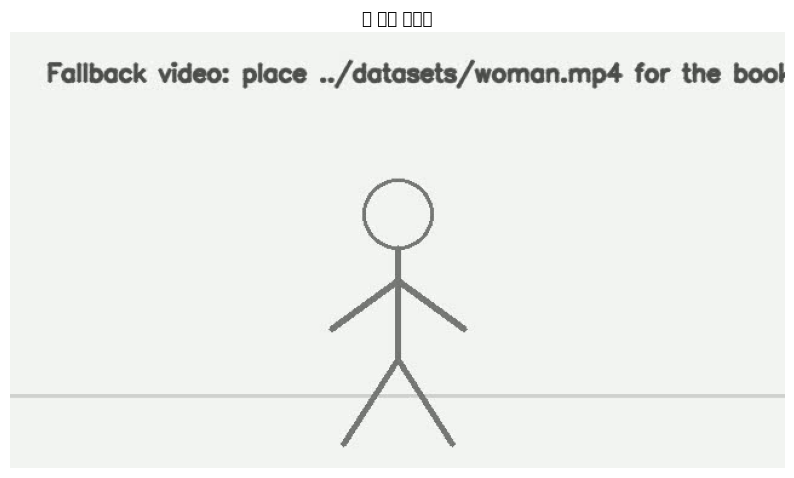

In [4]:
capture = cv2.VideoCapture(str(ACTIVE_VIDEO_PATH))

if not capture.isOpened():
    raise FileNotFoundError(f"비디오 파일을 열 수 없습니다: {ACTIVE_VIDEO_PATH}")

frame_count = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
current_frame_index = int(capture.get(cv2.CAP_PROP_POS_FRAMES))

ret, frame = capture.read()
capture.release()

if not ret:
    raise RuntimeError("첫 번째 프레임을 읽지 못했습니다.")

print(f"전체 프레임 수: {frame_count}")
print(f"읽기 전 현재 프레임 위치: {current_frame_index}")
print(f"첫 프레임 shape: {frame.shape}")

show_bgr(frame, "첫 번째 프레임")

### 선택 실행: OpenCV 창으로 비디오 보기

아래 함수는 책의 `cv2.imshow()` 방식과 같은 흐름입니다.  
다만 노트북을 자동 실행할 때 멈추지 않도록 함수만 정의하고 직접 호출하지는 않습니다.

로컬 VSCode에서 OpenCV 창을 띄워 확인하고 싶을 때만 다음처럼 실행하면 됩니다.

```python
play_video_opencv(max_frames=300)
```

In [5]:
def play_video_opencv(video_path=ACTIVE_VIDEO_PATH, delay=10, max_frames=None):
    """
    OpenCV 창으로 비디오를 재생하는 함수입니다.
    노트북 자동 실행에서는 호출하지 않는 것을 권장합니다.
    """
    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        raise FileNotFoundError(f"비디오 파일을 열 수 없습니다: {video_path}")

    frames_played = 0

    while cv2.waitKey(delay) < 0:
        if capture.get(cv2.CAP_PROP_POS_FRAMES) == capture.get(cv2.CAP_PROP_FRAME_COUNT):
            capture.set(cv2.CAP_PROP_POS_FRAMES, 0)

        ret, frame = capture.read()
        if not ret:
            break

        cv2.imshow("VideoFrame", frame)

        frames_played += 1
        if max_frames is not None and frames_played >= max_frames:
            break

    capture.release()
    cv2.destroyAllWindows()

# 직접 창을 띄워 보고 싶을 때만 아래 주석을 해제하세요.
# play_video_opencv(max_frames=300)

## 4. YOLOv8 모델 추론 함수 만들기

### 책 코드: 예제 9.27 모델 추론

```python
import torch

def predict(frame, iou=0.7, conf=0.25):
    results = model(
        source=frame,
        device="0" if torch.cuda.is_available() else "cpu",
        iou=0.7,
        conf=0.25,
        verbose=False,
    )
    result = results[0]
    return result
```

### 설명 요약

- `source=frame`에는 추론할 이미지 또는 비디오 프레임을 넣습니다.
- `device="0"`은 첫 번째 GPU를 의미합니다.
- GPU가 없으면 `cpu`로 실행합니다.
- `iou`는 중복 경계 상자를 제거할 때 사용하는 IoU 기준입니다.
- `conf`는 confidence threshold입니다. 이 값보다 낮은 예측은 제거됩니다.
- `verbose=False`는 추론 로그 출력을 줄이기 위한 설정입니다.

아래 실행용 함수는 책 코드와 같은 기본값을 사용하되, 함수 인자로 받은 `iou`, `conf` 값이 실제 추론에 반영되도록 작성했습니다.

In [6]:
import torch

def predict(frame, iou=0.7, conf=0.25):
    """
    YOLOv8 pose 모델로 한 프레임을 추론합니다.
    """
    results = model(
        source=frame,
        device="0" if torch.cuda.is_available() else "cpu",
        iou=iou,
        conf=conf,
        verbose=False,
    )
    result = results[0]
    return result

result = predict(frame)

print("추론 완료")
print(f"결과 객체 타입: {type(result)}")

추론 완료
결과 객체 타입: <class 'ultralytics.engine.results.Results'>


## 5. YOLOv8 추론 결과 객체 확인하기

책에서는 `results[0]` 또는 `result` 객체를 출력하여 YOLOv8이 어떤 속성을 반환하는지 확인합니다.

대표적인 속성은 다음과 같습니다.

| 속성 | 의미 |
|---|---|
| `boxes` | 경계 상자 예측 결과 |
| `keypoints` | 포즈 추정 키 포인트 결과 |
| `masks` | 세그멘테이션 결과가 있을 때 사용 |
| `names` | 클래스 ID와 클래스 이름 매핑 |
| `orig_img` | 원본 이미지 |
| `orig_shape` | 원본 이미지 크기 |
| `path` | 입력 경로 또는 이미지 이름 |
| `probs` | 분류 모델에서 사용하는 확률 |
| `speed` | 전처리, 추론, 후처리 시간 정보 |

In [7]:
# result 객체 요약 출력
print("result.keys:", getattr(result, "keys", None))
print("result.names:", getattr(result, "names", None))
print("result.orig_shape:", getattr(result, "orig_shape", None))
print("result.path:", getattr(result, "path", None))
print("result.speed:", getattr(result, "speed", None))

print("\nboxes 객체:")
print(result.boxes)

print("\nkeypoints 객체:")
print(result.keypoints)

result.keys: None
result.names: {0: 'person'}
result.orig_shape: (360, 640)
result.path: image0.jpg
result.speed: {'preprocess': 2.2762021981179714, 'inference': 64.90685604512691, 'postprocess': 4.572572652250528}

boxes 객체:
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([], device='cuda:0')
conf: tensor([], device='cuda:0')
data: tensor([], device='cuda:0', size=(0, 6))
id: None
is_track: False
orig_shape: (360, 640)
shape: torch.Size([0, 6])
xywh: tensor([], device='cuda:0', size=(0, 4))
xywhn: tensor([], device='cuda:0', size=(0, 4))
xyxy: tensor([], device='cuda:0', size=(0, 4))
xyxyn: tensor([], device='cuda:0', size=(0, 4))

keypoints 객체:
ultralytics.engine.results.Keypoints object with attributes:

conf: tensor([], device='cuda:0', size=(0, 17))
data: tensor([], device='cuda:0', size=(0, 17, 3))
has_visible: True
orig_shape: (360, 640)
shape: torch.Size([0, 17, 3])
xy: tensor([], device='cuda:0', size=(0, 17, 2))
xyn: tensor([], device='cuda:0', size=(0, 

### 책의 출력 흐름에 맞춘 `result`와 `result.boxes` 확인

책의 예시에서는 `result`를 출력한 뒤, 경계 상자 정보만 따로 확인하기 위해 `results[0].boxes`를 출력합니다.

아래 셀은 같은 목적의 확인 셀입니다.

In [8]:
# 노트북에서 result 객체 자체를 확인합니다.
result

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: ultralytics.engine.results.Keypoints object
masks: None
names: {0: 'person'}
obb: None
orig_img: array([[[241, 244, 242],
        [241, 244, 242],
        [241, 244, 242],
        ...,
        [241, 244, 242],
        [241, 244, 242],
        [241, 244, 242]],

       [[241, 244, 242],
        [241, 244, 242],
        [241, 244, 242],
        ...,
        [241, 244, 242],
        [241, 244, 242],
        [241, 244, 242]],

       [[241, 244, 242],
        [241, 244, 242],
        [241, 244, 242],
        ...,
        [241, 244, 242],
        [241, 244, 242],
        [241, 244, 242]],

       ...,

       [[241, 244, 242],
        [241, 244, 242],
        [241, 244, 242],
        ...,
        [241, 244, 242],
        [241, 244, 242],
        [241, 244, 242]],

       [[241, 244, 242],
        [241, 244, 242],
        [241, 244, 242],
        ...,
        [241, 244, 242],

In [9]:
# 경계 상자 속성만 따로 확인합니다.
result.boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([], device='cuda:0')
conf: tensor([], device='cuda:0')
data: tensor([], device='cuda:0', size=(0, 6))
id: None
is_track: False
orig_shape: (360, 640)
shape: torch.Size([0, 6])
xywh: tensor([], device='cuda:0', size=(0, 4))
xywhn: tensor([], device='cuda:0', size=(0, 4))
xyxy: tensor([], device='cuda:0', size=(0, 4))
xyxyn: tensor([], device='cuda:0', size=(0, 4))

In [10]:
# boxes.data는 보통 [x1, y1, x2, y2, conf, cls] 구조입니다.
if result.boxes is not None and result.boxes.data is not None:
    print("boxes.data shape:", tuple(result.boxes.data.shape))
    print(result.boxes.data)
else:
    print("검출된 경계 상자가 없습니다.")

boxes.data shape: (0, 6)
tensor([], device='cuda:0', size=(0, 6))


## 6. 경계 상자 시각화하기

### 책 코드: 예제 9.28 경계 상자 시각화

```python
def draw_boxes(result, frame):
    for boxes in result.boxes:
        x1, y1, x2, y2, score, classes = boxes.data.squeeze().cpu().numpy()
        cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), (0, 0, 255), 1)
    return frame
```

### 설명 요약

- `result.boxes`에는 검출된 객체의 경계 상자 정보가 들어 있습니다.
- `boxes.data`는 보통 `[x1, y1, x2, y2, conf, cls]` 형식입니다.
- `x1, y1`은 좌상단 좌표이고, `x2, y2`는 우하단 좌표입니다.
- `cv2.rectangle(...)`은 이미지에 사각형을 그립니다.
- OpenCV 색상은 RGB가 아니라 BGR 순서이므로 `(0, 0, 255)`는 빨간색입니다.

아래 실행용 함수는 원본 프레임을 직접 바꾸지 않도록 `frame.copy()`를 사용합니다.

/home/jiheechoi0102/jihi/jihi/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jiheechoi0102/jihi/jihi/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jiheechoi0102/jihi/jihi/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jiheechoi0102/jihi/jihi/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jiheechoi0102/jihi/jihi/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGU

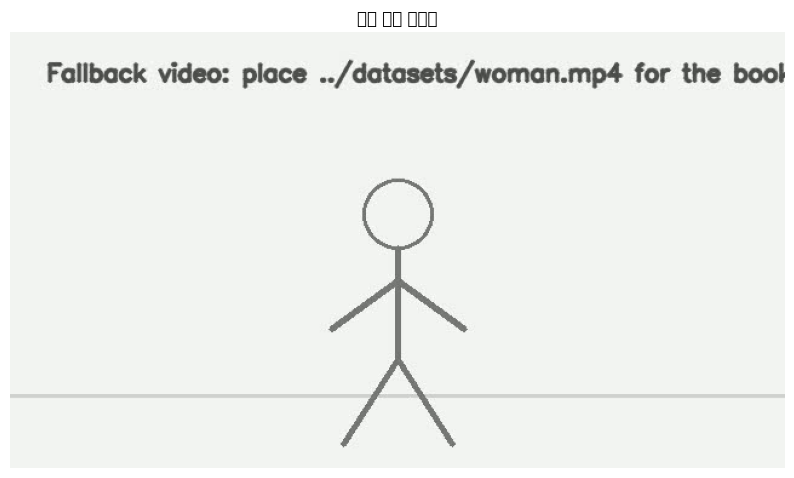

In [11]:
def draw_boxes(result, frame):
    """
    YOLOv8 결과 객체의 boxes를 이용해 경계 상자를 그립니다.
    """
    annotated_frame = frame.copy()

    if result.boxes is None or result.boxes.data is None:
        return annotated_frame

    for boxes in result.boxes:
        values = boxes.data.squeeze().detach().cpu().numpy()

        # 검출 결과가 비어 있거나 예상보다 짧으면 건너뜁니다.
        if values.size < 6:
            continue

        x1, y1, x2, y2, score, classes = values[:6]
        cv2.rectangle(
            annotated_frame,
            (int(x1), int(y1)),
            (int(x2), int(y2)),
            (0, 0, 255),
            1,
        )

    return annotated_frame

boxed_frame = draw_boxes(result, frame)
show_bgr(boxed_frame, "경계 상자 시각화")

## 7. 비디오 프레임에 모델 추론과 경계 상자 시각화 적용하기

### 책 코드: 예제 9.29 모델 추론 및 시각화 적용

```python
...

ret, frame = capture.read()
result = predict(frame)
frame = draw_boxes(result, frame)
cv2.imshow("VideoFrame", frame)

...
```

### 설명 요약

이 코드는 예제 9.26의 비디오 읽기 루프 안에 모델 추론과 경계 상자 그리기를 추가한 것입니다.  
즉, 매 프레임마다 다음 순서로 처리합니다.

1. 비디오에서 프레임을 읽음
2. YOLOv8 pose 모델로 프레임을 추론함
3. 추론 결과의 경계 상자를 프레임에 그림
4. OpenCV 창에 결과를 표시함

In [12]:
def process_video_boxes(video_path=ACTIVE_VIDEO_PATH, output_path=OUTPUT_DIR / "video_boxes.mp4", max_frames=60):
    """
    비디오를 읽어 각 프레임에 경계 상자를 그린 뒤 새 mp4 파일로 저장합니다.
    CPU 환경에서는 오래 걸릴 수 있어 max_frames로 처리 프레임 수를 제한할 수 있습니다.
    """
    video_path = Path(video_path)
    output_path = Path(output_path)

    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        raise FileNotFoundError(f"비디오 파일을 열 수 없습니다: {video_path}")

    fps = capture.get(cv2.CAP_PROP_FPS)
    if fps <= 0:
        fps = 20

    width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))

    frame_idx = 0

    while True:
        ret, frame = capture.read()
        if not ret:
            break

        result = predict(frame)
        frame = draw_boxes(result, frame)
        writer.write(frame)

        frame_idx += 1
        if max_frames is not None and frame_idx >= max_frames:
            break

    capture.release()
    writer.release()

    return output_path

# 비디오 전체 처리는 시간이 걸릴 수 있으므로 기본값은 False입니다.
RUN_BOX_VIDEO_EXPORT = False

if RUN_BOX_VIDEO_EXPORT:
    box_video_path = process_video_boxes(max_frames=60)
    print(f"경계 상자 비디오 저장 완료: {box_video_path}")
else:
    print("비디오 저장은 건너뜁니다. 실행하려면 RUN_BOX_VIDEO_EXPORT = True로 바꾸세요.")

비디오 저장은 건너뜁니다. 실행하려면 RUN_BOX_VIDEO_EXPORT = True로 바꾸세요.


## 8. 키 포인트 시각화하기

### 책 코드: 예제 9.30 키 포인트 시각화

```python
from ultralytics.yolo.utils.plotting import Annotator

def draw_keypoints(result, frame):
    annotator = Annotator(frame, line_width=1)
    for kps in result.keypoints:
        kps = kps.data.squeeze()
        annotator.kpts(kps)
        nkps = kps.cpu().numpy()
        # nkps[:, 2] = 1
        # annotator.kpts(nkps)
        for idx, (x, y, score) in enumerate(nkps):
            if score > 0.5:
                cv2.circle(frame, (int(x), int(y)), 3, (0, 0, 255), cv2.FILLED)
                cv2.putText(
                    frame, str(idx), (int(x), int(y)), cv2.FONT_HERSHEY_COMPLEX,
                    1, (0, 0, 255), 1
                )

    return frame
```

### 설명 요약

- `Annotator`는 Ultralytics에서 제공하는 시각화 도구입니다.
- `result.keypoints`에는 사람의 신체 주요 지점 좌표가 들어 있습니다.
- MS COCO 포즈 형식에서는 17개의 신체 부위를 예측합니다.
- keypoint 하나는 보통 `[x, y, conf]` 구조입니다.
- `conf`가 0.5보다 큰 keypoint만 점과 번호로 표시합니다.
- `cv2.circle(...)`은 점을 그리고, `cv2.putText(...)`는 keypoint ID를 씁니다.

아래 실행용 함수는 Ultralytics 버전 차이와 keypoint가 없는 경우를 함께 처리합니다.

/home/jiheechoi0102/jihi/jihi/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53412 (\N{HANGUL SYLLABLE KI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jiheechoi0102/jihi/jihi/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jiheechoi0102/jihi/jihi/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jiheechoi0102/jihi/jihi/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


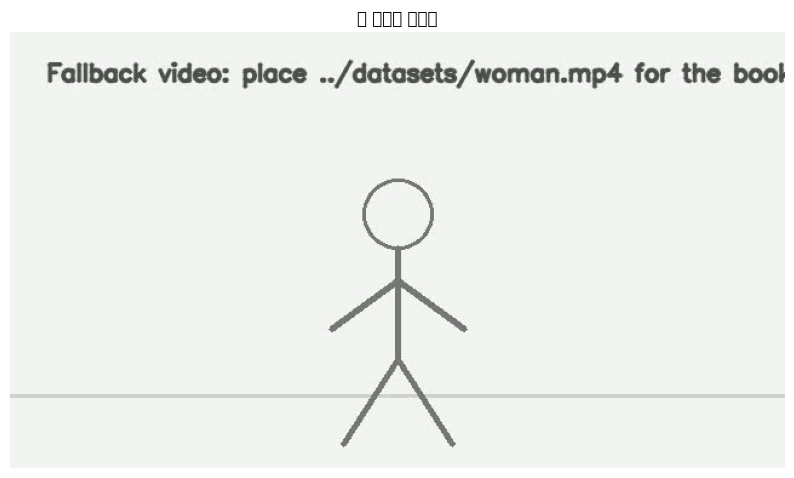

In [13]:
KEYPOINT_NAMES_KO = {
    0: "코",
    1: "왼쪽 눈",
    2: "오른쪽 눈",
    3: "왼쪽 귀",
    4: "오른쪽 귀",
    5: "왼쪽 어깨",
    6: "오른쪽 어깨",
    7: "왼쪽 팔꿈치",
    8: "오른쪽 팔꿈치",
    9: "왼쪽 손목",
    10: "오른쪽 손목",
    11: "왼쪽 골반",
    12: "오른쪽 골반",
    13: "왼쪽 무릎",
    14: "오른쪽 무릎",
    15: "왼쪽 발목",
    16: "오른쪽 발목",
}

def draw_keypoints(result, frame, threshold=0.5, draw_ids=True, draw_skeleton=True):
    """
    YOLOv8 pose 결과의 keypoints를 이용해 프레임에 신체 키 포인트를 그립니다.
    """
    annotated_frame = frame.copy()

    if result.keypoints is None or getattr(result.keypoints, "data", None) is None:
        return annotated_frame

    keypoints_data = result.keypoints.data.detach().cpu().numpy()

    # 일반적으로 shape은 [사람 수, 17, 3]입니다.
    # 사람 1명만 있을 때 [17, 3]처럼 들어오는 경우도 방어합니다.
    if keypoints_data.ndim == 2:
        keypoints_data = keypoints_data[None, ...]

    # 1) Ultralytics Annotator로 skeleton을 먼저 그립니다.
    if draw_skeleton:
        try:
            annotator = Annotator(annotated_frame, line_width=1)
            for one_person_kps in keypoints_data:
                annotator.kpts(one_person_kps)
            if hasattr(annotator, "result"):
                annotated_frame = annotator.result()
        except Exception as e:
            print(f"Annotator skeleton 시각화는 건너뜁니다: {e}")

    # 2) 각 keypoint 위치에 점과 ID를 추가합니다.
    for one_person_kps in keypoints_data:
        # keypoint가 [x, y]만 가진 경우 confidence를 1로 보정합니다.
        if one_person_kps.shape[-1] == 2:
            scores = np.ones((one_person_kps.shape[0], 1), dtype=one_person_kps.dtype)
            one_person_kps = np.concatenate([one_person_kps, scores], axis=1)

        for idx, values in enumerate(one_person_kps):
            x, y, score = values[:3]

            if score > threshold and x > 0 and y > 0:
                cv2.circle(
                    annotated_frame,
                    (int(x), int(y)),
                    3,
                    (0, 0, 255),
                    cv2.FILLED,
                )

                if draw_ids:
                    cv2.putText(
                        annotated_frame,
                        str(idx),
                        (int(x), int(y)),
                        cv2.FONT_HERSHEY_COMPLEX,
                        1,
                        (0, 0, 255),
                        1,
                    )

    return annotated_frame

keypoint_frame = draw_keypoints(result, frame)
show_bgr(keypoint_frame, "키 포인트 시각화")

## 9. MS COCO 포즈 키 포인트 ID 정리

책의 표에서는 YOLOv8 pose 결과가 따르는 17개 keypoint ID의 의미를 정리합니다.

| ID | 의미 | ID | 의미 |
|---:|---|---:|---|
| 0 | 코 | 9 | 왼쪽 손목 |
| 1 | 왼쪽 눈 | 10 | 오른쪽 손목 |
| 2 | 오른쪽 눈 | 11 | 왼쪽 골반 |
| 3 | 왼쪽 귀 | 12 | 오른쪽 골반 |
| 4 | 오른쪽 귀 | 13 | 왼쪽 무릎 |
| 5 | 왼쪽 어깨 | 14 | 오른쪽 무릎 |
| 6 | 오른쪽 어깨 | 15 | 왼쪽 발목 |
| 7 | 왼쪽 팔꿈치 | 16 | 오른쪽 발목 |
| 8 | 오른쪽 팔꿈치 |  |  |

In [14]:
for idx, name in KEYPOINT_NAMES_KO.items():
    print(f"{idx:2d}: {name}")

 0: 코
 1: 왼쪽 눈
 2: 오른쪽 눈
 3: 왼쪽 귀
 4: 오른쪽 귀
 5: 왼쪽 어깨
 6: 오른쪽 어깨
 7: 왼쪽 팔꿈치
 8: 오른쪽 팔꿈치
 9: 왼쪽 손목
10: 오른쪽 손목
11: 왼쪽 골반
12: 오른쪽 골반
13: 왼쪽 무릎
14: 오른쪽 무릎
15: 왼쪽 발목
16: 오른쪽 발목


## 10. 경계 상자와 키 포인트를 함께 적용하기

앞에서 만든 `predict`, `draw_boxes`, `draw_keypoints`를 하나의 프레임에 순서대로 적용합니다.

처리 순서는 다음과 같습니다.

1. 비디오 첫 프레임 읽기
2. YOLOv8 pose 모델 추론
3. 경계 상자 그리기
4. 키 포인트 그리기
5. 결과 이미지를 노트북에 표시하고 파일로 저장

최종 결과 이미지 저장 경로: outputs_yolov8_pose/first_frame_pose_result.jpg


/home/jiheechoi0102/jihi/jihi/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jiheechoi0102/jihi/jihi/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jiheechoi0102/jihi/jihi/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jiheechoi0102/jihi/jihi/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


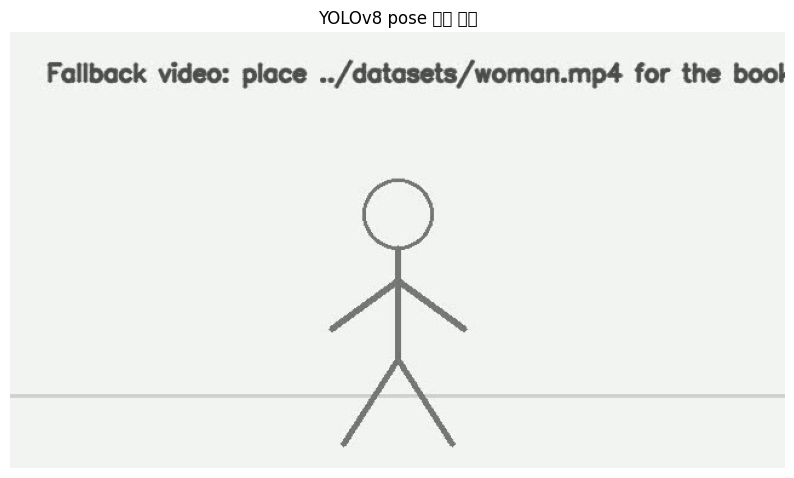

In [15]:
def run_pose_on_first_frame(video_path=ACTIVE_VIDEO_PATH, output_path=OUTPUT_DIR / "first_frame_pose_result.jpg"):
    """
    비디오 첫 프레임에 YOLOv8 pose 추론, 경계 상자, 키 포인트를 모두 적용합니다.
    """
    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        raise FileNotFoundError(f"비디오 파일을 열 수 없습니다: {video_path}")

    ret, frame = capture.read()
    capture.release()

    if not ret:
        raise RuntimeError("비디오 첫 프레임을 읽지 못했습니다.")

    result = predict(frame)
    output_frame = draw_boxes(result, frame)
    output_frame = draw_keypoints(result, output_frame)

    cv2.imwrite(str(output_path), output_frame)
    return output_frame, output_path

final_frame, final_image_path = run_pose_on_first_frame()
print(f"최종 결과 이미지 저장 경로: {final_image_path}")
show_bgr(final_frame, "YOLOv8 pose 최종 결과")

## 11. 비디오 전체에 포즈 추정 적용하기

아래 함수는 비디오의 여러 프레임에 대해 경계 상자와 키 포인트를 모두 그린 뒤 새 영상 파일로 저장합니다.

CPU 환경에서는 느릴 수 있으므로 기본 실행은 꺼 두었습니다.  
실제로 저장하려면 `RUN_POSE_VIDEO_EXPORT = True`로 바꾼 뒤 실행하면 됩니다.

In [16]:
def process_video_pose(video_path=ACTIVE_VIDEO_PATH, output_path=OUTPUT_DIR / "video_pose_result.mp4", max_frames=60):
    """
    비디오 각 프레임에 YOLOv8 pose 추론 결과를 시각화하여 저장합니다.
    """
    video_path = Path(video_path)
    output_path = Path(output_path)

    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        raise FileNotFoundError(f"비디오 파일을 열 수 없습니다: {video_path}")

    fps = capture.get(cv2.CAP_PROP_FPS)
    if fps <= 0:
        fps = 20

    width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))

    frame_idx = 0

    while True:
        ret, frame = capture.read()
        if not ret:
            break

        result = predict(frame)
        frame = draw_boxes(result, frame)
        frame = draw_keypoints(result, frame)
        writer.write(frame)

        frame_idx += 1
        if max_frames is not None and frame_idx >= max_frames:
            break

    capture.release()
    writer.release()

    return output_path

RUN_POSE_VIDEO_EXPORT = False

if RUN_POSE_VIDEO_EXPORT:
    pose_video_path = process_video_pose(max_frames=60)
    print(f"포즈 추정 비디오 저장 완료: {pose_video_path}")
else:
    print("비디오 저장은 건너뜁니다. 실행하려면 RUN_POSE_VIDEO_EXPORT = True로 바꾸세요.")

비디오 저장은 건너뜁니다. 실행하려면 RUN_POSE_VIDEO_EXPORT = True로 바꾸세요.


## 12. 실습 전체 코드 흐름 요약

이번 실습의 핵심 흐름은 다음과 같습니다.

| 단계 | 핵심 코드 | 역할 |
|---|---|---|
| 1 | `YOLO("../models/yolov8m-pose.pt")` | YOLOv8 pose 모델 로드 |
| 2 | `cv2.VideoCapture(...)` | 비디오 파일 열기 |
| 3 | `capture.read()` | 프레임 읽기 |
| 4 | `model(source=frame, ...)` | 한 프레임에 대한 포즈 추정 |
| 5 | `result.boxes` | 경계 상자 정보 확인 |
| 6 | `result.keypoints` | 신체 keypoint 정보 확인 |
| 7 | `cv2.rectangle(...)` | 경계 상자 그리기 |
| 8 | `Annotator(...).kpts(...)` | keypoint skeleton 그리기 |
| 9 | `cv2.circle(...)`, `cv2.putText(...)` | keypoint 점과 ID 표시 |
| 10 | `cv2.imwrite(...)`, `cv2.VideoWriter(...)` | 결과 이미지 또는 비디오 저장 |

실제 제출 시에는 `../models/yolov8m-pose.pt`와 `../datasets/woman.mp4` 파일을 책의 실습 자료 위치에 맞춰 배치하면 책과 같은 입력으로 실행할 수 있습니다.